In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import spearmanr


from alibi.explainers import ALE
from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt

from sklearn.linear_model import Ridge
import time
from copy import deepcopy

from collections import defaultdict
from joblib import Parallel, delayed

In [16]:
from copy import deepcopy

from typing import Dict, Tuple, List
from fixait import CalcFeatureWeight
from xai_faithfulness_tuner import fiXAItImportanceTuner

path = "dataset/compas.csv"
group_size=7
pick_mdl= CatBoostClassifier(
    iterations=200,
    learning_rate=0.01,
    depth=3,
    subsample=0.90,     
    rsm=0.90,              
    bootstrap_type="Bernoulli",
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_seed=42,
    verbose=False
)

#pick_mdl = XGBClassifier(n_estimators=220, learning_rate=0.01, max_depth=4, subsample=0.80,  random_state=42)

# pick_mdl =RandomForestClassifier(n_estimators=20, min_samples_leaf=7, random_state=42)
#pick_mdl = make_vit_classifier(max_epochs=10)

def prune_p_opt_q_val(
    p_opt: Dict[str, float],
    q_val: Dict[str, float],
    threshold_pct: float = 3.0,
    inclusive: bool = True,   # True => x% and below are eliminated
    drop_zeros: bool = True   # True => 0 and negatives are eliminated
) -> Tuple[Dict[str, float], Dict[str, float], List[str]]:
    """
    Drops are decided ONLY by p_opt:
      1) Drop negatives (and optionally zeros) from p_opt.
      2) For remaining positives in p_opt: compute share = v/sum_pos, drop if share <= threshold.
      3) Apply same drops to BOTH p_opt and q_val (keep them aligned).
      4) Round remaining values to 3 decimals in BOTH dicts.
    """

    p = {k: float(v) for k, v in p_opt.items()}
    q = {k: float(v) for k, v in q_val.items()}

    # 1) non-positive drop based on p_opt only
    if drop_zeros:
        drop = {k for k, v in p.items() if v <= 0.0}
    else:
        drop = {k for k, v in p.items() if v < 0.0}

    # 2) threshold drop by p_opt positive shares (RAW values, no rounding before thresholding)
    pos = {k: v for k, v in p.items() if k not in drop and v > 0.0}
    s = sum(pos.values())
    thr = float(threshold_pct) / 100.0

    if s > 0:
        for k, v in pos.items():
            share = v / s
            if inclusive:
                if share <= thr:
                    drop.add(k)
            else:
                if share < thr:
                    drop.add(k)

    # 3) apply to both and keep aligned keys
    kept = sorted((set(p.keys()) & set(q.keys())) - drop)

    # 4) round to 3 decimals
    p_clean = {k: round(p[k], 3) for k in kept}
    q_clean = {k: round(q[k], 3) for k in kept}

    return p_clean, q_clean, sorted(drop)

# 1) Generate p (existence impact) (plots closed)
cfw = CalcFeatureWeight(
    data_path=path,
    model=pick_mdl,
    group_size=group_size,
    n_jobs=-1,
    plot=False,

    # Opt/Eval distinction (60/20/20)
    test_size=0.15,
    opt_size=0.20,
    stratify=True,
    random_state=42,
    verbose=False
)

p_exist = cfw.new_weight_format      
q_val   = cfw.compute_value_impact() 
#print("RAW p_exist:", p_exist)

# 2) Buy split+scale all at once.
split = cfw.get_splits()

X_train = pd.DataFrame(split.X_train, columns=split.feature_names)
y_train = pd.Series(split.y_train)

X_opt  = pd.DataFrame(split.X_opt, columns=split.feature_names)
y_opt  = pd.Series(split.y_opt)

X_eval = pd.DataFrame(split.X_test, columns=split.feature_names)
y_eval = pd.Series(split.y_test)

# 3) Fit the model once (with full features)
model_fitted = deepcopy(pick_mdl)
model_fitted.fit(X_train, y_train)


# 4) Tuner: Automatically retrieves splits from CalcFeatureWeight (no PATH, no resplit)
p_opt, faith0, faith1, drop0, drop1 = fiXAItImportanceTuner(
    cfw=cfw,
    model=model_fitted,
    p_exist=p_exist,

    runs_per_feature=30,
    n_jobs=-1,
    prefer="threads", 
    verbose=False
)

p, q, dropped_features = prune_p_opt_q_val(
    p_opt=p_opt,
    q_val=q_val,
    threshold_pct=3,
    inclusive=True,
    drop_zeros=True
)

print("fiXAIt calculations were performed and the calculated feature importance values ​​were optimized.")

fiXAIt calculations were performed and the calculated feature importance values ​​were optimized.


In [17]:
# Calculate the sum of absolute values
val_sum = sum(abs(value) for value in q.values())

# Calculate the proportional value for each Value Impact
q = {key: (value / val_sum) for key, value in q.items()}
z = p.keys()
pp = []  # Existence Impact
qq = []  # Value Impact

for key in z:
    pp.append(p.get(key))
    qq.append(q.get(key))

data = {
    'Feature': z,
    'Existence Impact': pp,
    'Value Impact': qq
}

df = pd.DataFrame(data)

# Create a numeric Value Impact column
df['Value Impact Numeric'] = pd.to_numeric(df['Value Impact'], errors='coerce')

# Value Impact is categorized
df['Value Impact'] = df['Value Impact Numeric'].apply(
    lambda x: "Insignificant" if pd.notnull(x) and abs(x) < 0.025 else
              ("Positive" if pd.notnull(x) and x > 0 else "Negative")
)

# We take the absolute values of the impact values so that we do not see a negative sign on the graph. Because we are already expressing it with symbols.
df['Value Impact Numeric'] = df['Value Impact Numeric'].round(2)
df['Value Impact Numeric'] = df['Value Impact Numeric'].abs()
df['Value Impact Numeric'] = df['Value Impact Numeric'].apply(lambda x: "∅" if x <= 0.025 else x)

chart = alt.Chart(df).mark_bar().encode(
    x=alt.X('Existence Impact', title='Existence Impact'),
    y=alt.Y('Feature', title='Feature', sort='-x'),
    color=alt.condition(
        alt.datum['Existence Impact'] > 0,
        alt.value('cornflowerblue'),  # Blue for positive values
        alt.value('orange')  # Blue for negative values
    ),
    tooltip=['Feature', 'Existence Impact', 'Value Impact Numeric']
).properties(
    title='Existence Impact and Value Impact',
    width=800,
    height=300
)

text = chart.mark_text(align='left', dx=10, fontSize=24).encode(
    text=alt.Text('Value Impact Numeric'),
    color=alt.value('darkslategray')
)

arrows = alt.Chart(df).mark_point(size=400, filled=True).encode(
    x=alt.X('Existence Impact'),
    y=alt.Y('Feature', sort='-x', axis=alt.Axis(offset=-0.5)),

    shape=alt.Shape(
        'Value Impact',
        type='nominal',
        scale=alt.Scale(
            domain=["Negative", "Positive", "Insignificant"],
            range=["triangle-down", "triangle-up", "circle"]
        ),
        legend=None
    ),

    color=alt.Color(
        'Value Impact',
        type='nominal',
        scale=alt.Scale(
            domain=["Negative", "Positive", "Insignificant"],
            range=["firebrick", "green", "dimgray"]
        ),
        legend=alt.Legend(title="Value Impact", titleFontSize=20, labelFontSize=20, symbolSize=150)
    ),

    tooltip=['Feature', 'Existence Impact', 'Value Impact Numeric']
)

final_chart = (chart + text + arrows).interactive()

final_chart = final_chart.configure_axis(
    labelFontSize=24,
    titleFontSize=24
).configure_title(
    fontSize=22
)

final_chart.save('exist_impact_graph_v14.json')
final_chart

alt.LayerChart(...)

In [18]:
df_table = df.copy()
df_table = df_table[['Feature', 'Existence Impact', 'Value Impact Numeric', 'Value Impact']]
df_table = df_table.sort_values(by='Existence Impact', ascending=False)

df_table['Existence Impact'] = df_table['Existence Impact'].round(4)
df_table['Value Impact Numeric'] = df_table['Value Impact Numeric'].round(4)

lines = []
lines.append("Features\t" + "\t".join(df_table['Feature']))
lines.append("Existence Impact\t" + "\t".join(map(str, df_table['Existence Impact'])))
lines.append("Value Impact Num\t" + "\t".join(map(str, df_table['Value Impact Numeric'])))
lines.append("Value Impact Sign\t" + "\t".join(df_table['Value Impact']))


In [19]:
import warnings
warnings.filterwarnings("ignore")

import time
import shap

# ---------------------------------------
# SHAP + Feature importance + Accuracy
# ---------------------------------------

shap_start_time = time.time()

# Load dataset
shap_data = pd.read_csv(path)
shap_target = shap_data["class"].copy()
shap_features = shap_data.drop(columns=["class"]).copy()

# Split
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(
    shap_features, shap_target, test_size=0.2, random_state=42
)

# Train a fresh copy of the model
shap_model = deepcopy(pick_mdl)
shap_model.fit(X_train_shap, y_train_shap)

shap_feature_names = shap_features.columns.tolist()

# -------------------------
# Helper: unify shap values
# -------------------------
def compute_mean_abs_shap(shap_values):
    """
    Returns a 1D array of length n_features with mean(|shap|) across samples
    and across classes if multiclass.
    Supports:
      - list of arrays (per-class)
      - numpy arrays (2D or 3D)
      - shap.Explanation (has .values)
    """
    sv = shap_values

    # Explanation -> values
    if hasattr(sv, "values"):
        sv = sv.values

    # list case: [ (n_samples, n_features), ... ] per class
    if isinstance(sv, list):
        return np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)

    # array case
    sv = np.asarray(sv)

    if sv.ndim == 2:
        # (n_samples, n_features)
        return np.abs(sv).mean(axis=0)

    if sv.ndim == 3:
        # common possibilities:
        # (n_samples, n_classes, n_features) OR (n_classes, n_samples, n_features)
        # We'll detect which axis is n_features by matching last dim to features if possible.
        # Safest generic: average over all axes except last.
        return np.abs(sv).mean(axis=tuple(range(sv.ndim - 1)))

    raise ValueError(f"Unexpected SHAP shape: {sv.shape}")

# -------------------------
# Helper: accuracy function
# -------------------------
def compute_accuracy(ds_path, features, model):
    # features: Can be None or a feature list.
    # Let's not cause problems even if 'class' is accidentally inside the features.

    if features is None:
        df_sel = pd.read_csv(ds_path)  # all columns (including class)
    else:
        # Add the class by making it singular.
        cols = [c for c in features if c != 'class'] + ['class']
        # singularize (without changing the order)
        cols = list(dict.fromkeys(cols))
        df_sel = pd.read_csv(ds_path, usecols=cols)

    y = df_sel['class']
    Xf = df_sel.drop(columns=['class'])

    Xtr, Xte, ytr, yte = train_test_split(Xf, y, test_size=0.2, random_state=42)
    scaler = MinMaxScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

    model.fit(Xtr_s, ytr)
    return round(accuracy_score(yte, model.predict(Xte_s)), 3)

# -------------------------
# SHAP computation
# -------------------------
TREE_MODELS = (
    DecisionTreeClassifier,
    RandomForestClassifier,
    XGBClassifier,
    CatBoostClassifier,
    lgb.LGBMClassifier,
)

# XGBClassifier optional: include import if available
try:
    from xgboost import XGBClassifier
    TREE_MODELS = TREE_MODELS + (XGBClassifier,)
except Exception:
    pass

# -------------------------
# ADDITION: skip unsupported multiclass GBC (no Kernel fallback)
# -------------------------
n_classes = y_train_shap.nunique() if hasattr(y_train_shap, "nunique") else len(np.unique(y_train_shap))
skip_shap = isinstance(pick_mdl, GradientBoostingClassifier) and n_classes > 2

if skip_shap:
    warnings.warn(
        f"SHAP TreeExplainer does not support scikit-learn GradientBoostingClassifier for multiclass "
        f"(n_classes={n_classes}). SHAP computation will be skipped.",
        RuntimeWarning
    )
    shap_top_features, shap_top_values = [], []
# -------------------------

if isinstance(pick_mdl, TREE_MODELS) and (not skip_shap):
    explainer = shap.TreeExplainer(shap_model, feature_names=shap_feature_names)
    shap_values = explainer.shap_values(shap_features)

    shap_vals = compute_mean_abs_shap(shap_values)

    shap_importance_df = (
        pd.DataFrame({"col_name": shap_features.columns, "feature_importance": shap_vals})
        .sort_values(by="feature_importance", ascending=False)
        .reset_index(drop=True)
    )

    shap_top_features = shap_importance_df["col_name"].tolist()
    shap_top_values = shap_importance_df["feature_importance"].tolist()

else:
    shap_background = shap.sample(X_train_shap, min(100, len(X_train_shap)), random_state=42)

    if hasattr(shap_model, "predict_proba"):
        f = shap_model.predict_proba
    else:
        f = shap_model.predict

    explainer = shap.KernelExplainer(f, shap_background)
    shap_values = explainer.shap_values(X_test_shap)

    shap_vals = compute_mean_abs_shap(shap_values)

    shap_importance_df = (
        pd.DataFrame({"col_name": shap_features.columns, "feature_importance": shap_vals})
        .sort_values(by="feature_importance", ascending=False)
        .reset_index(drop=True)
    )

    shap_top_features = shap_importance_df["col_name"].tolist()
    shap_top_values = shap_importance_df["feature_importance"].tolist()

# -------------------------
# Top feature dict
# -------------------------
shap_dict = dict(zip(shap_top_features[:group_size], shap_top_values[:group_size]))

# Selected features (ONLY features, no class)
shap_selected_features = sorted(shap_top_features[:group_size])

# Accuracy with selected features (skip if no features)
if len(shap_selected_features) == 0:
    warnings.warn(
        "No SHAP-selected features are available because SHAP was skipped. "
        "Selected-features accuracy will be reported as N/A.",
        RuntimeWarning
    )
    shap_acc = "N/A"
else:
    shap_acc = str(compute_accuracy(path, shap_selected_features, deepcopy(pick_mdl))).replace(".", ",")

t_shap = time.time() - shap_start_time

print("Top features:", shap_selected_features[:10], "..." if len(shap_selected_features) > 10 else "")
print("SHAP acc:", shap_acc)
print("SHAP time (s):", round(t_shap, 2))


Top features: ['Age', 'CustodyStatus', 'Ethnicity', 'Gender', 'MaritalStatus', 'RecSupervisionLevel', 'ScaleID'] 
SHAP acc: 0,834
SHAP time (s): 1.91


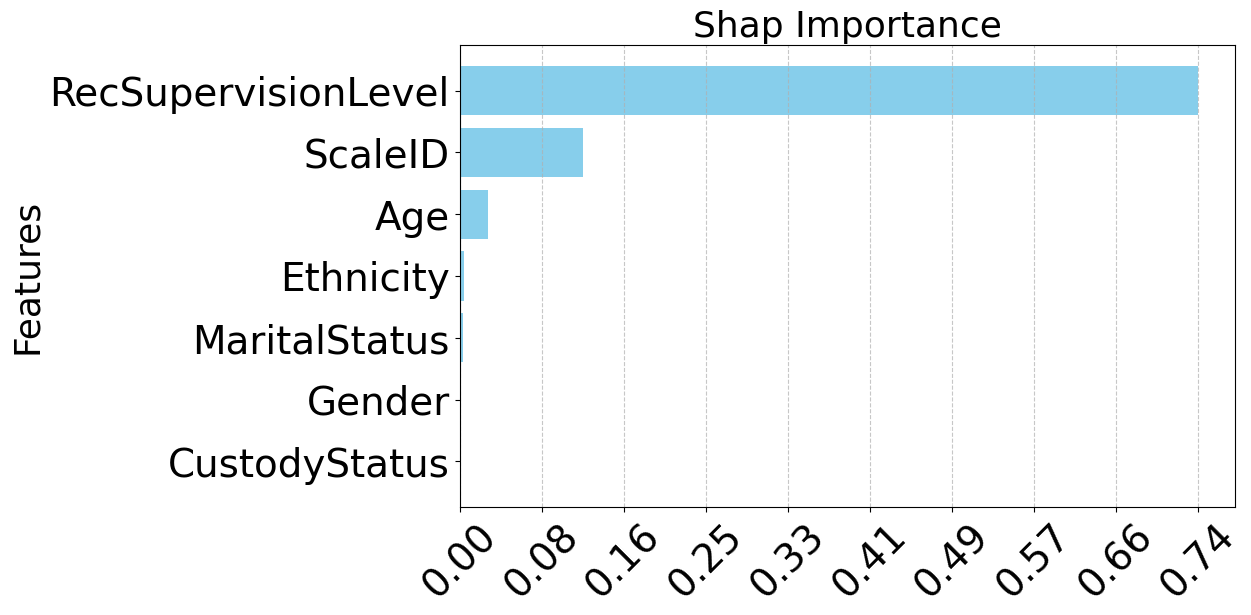

In [20]:
plt.figure(figsize=(10, 6))
plt.barh(shap_top_features[:group_size], shap_top_values[:group_size], color='skyblue')
plt.ylabel('Features', fontsize=26)     
xtick_values = np.linspace(min(shap_top_values), max(shap_top_values), num=10)
plt.xticks(xtick_values, fontsize=28, rotation=45)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(fontsize=28)
plt.title('Shap Importance', fontsize=26)
plt.gca().invert_yaxis()
plt.margins(x=0.05)
plt.show()


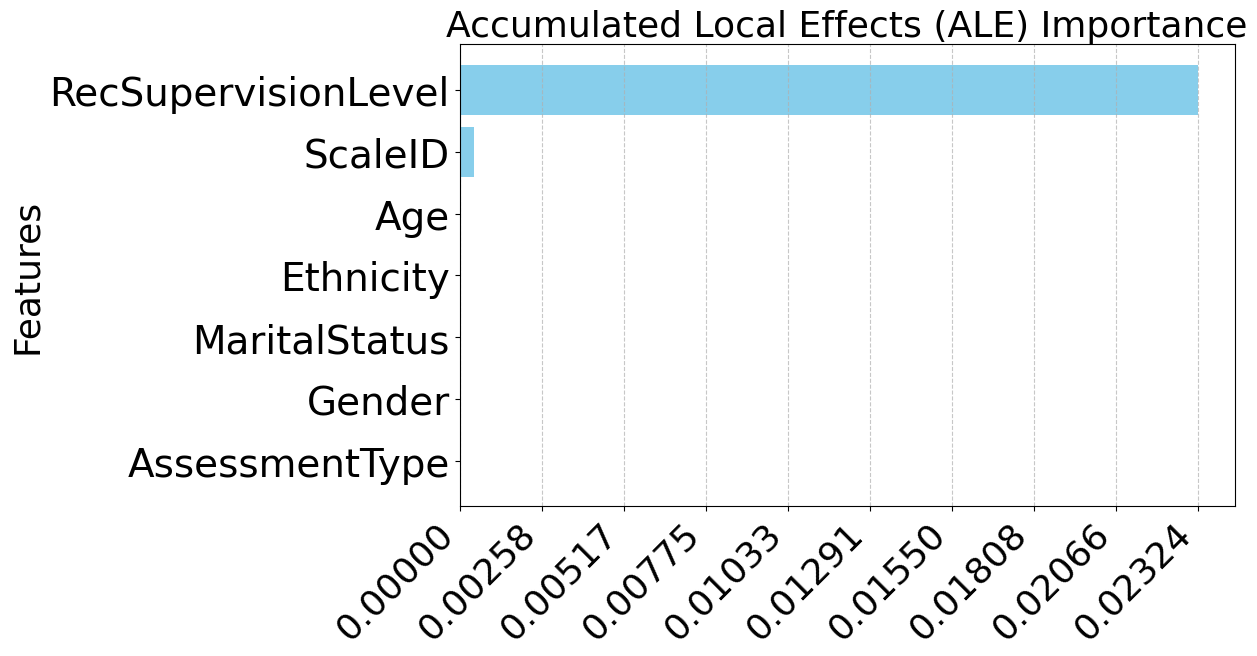

In [21]:
import logging
logging.getLogger('alibi').setLevel(logging.ERROR)

ale_start_time = time.time()  # Start measuring ALE execution time

# Load the dataset from the specified CSV path
ale_data = pd.read_csv(path)
ale_target = ale_data['class']  # Target variable (class labels)
ale_features_all = ale_data.drop(columns=['class'])  # Feature set

# Split the data into training and testing sets (ALE-specific)
X_train_ale, X_test_ale, y_train_ale, y_test_ale = train_test_split(
    ale_features_all, ale_target, test_size=0.2, random_state=42
)

# Preprocessor: pass through numeric columns as they are
ale_numeric_cols = ale_features_all.select_dtypes('number').columns
ale_preprocessor = ColumnTransformer([('num', 'passthrough', ale_numeric_cols)])

# Create a pipeline combining preprocessing and the model
ale_model_pipeline = Pipeline([
    ('prep', ale_preprocessor),
    ('clf', deepcopy(pick_mdl))  # Use a copy of the selected model
])

# Fit the model pipeline to the training data
ale_model_pipeline.fit(X_train_ale, y_train_ale)

# Define the prediction function for the ALE explainer
def ale_predict_fn(X_array):
    X_df = pd.DataFrame(X_array, columns=ale_features_all.columns)
    return ale_model_pipeline.predict_proba(X_df)

# Initialize the ALE (Accumulated Local Effects) explainer
ale_explainer = ALE(
    predictor=ale_predict_fn,  # Prediction function
    feature_names=ale_features_all.columns.tolist(),  # Feature names
    target_names=['neg', 'pos']  # Class names
)

# Generate grid points for each feature (20 points per feature)
ale_grid_resolution = 20
ale_feature_indices = list(range(X_test_ale.shape[1]))
ale_grid_points = {
    idx: np.linspace(
        X_test_ale.values[:, idx].min(),
        X_test_ale.values[:, idx].max(),
        ale_grid_resolution
    )
    for idx in ale_feature_indices
}

# Compute ALE explanations for the test data
ale_exp = ale_explainer.explain(
    X_test_ale.values,
    features=ale_feature_indices,
    grid_points=ale_grid_points
)

# Calculate feature importance based on the variance of ALE values
ale_variances = [np.var(vals[:, 1]) for vals in ale_exp.ale_values]
ale_feature_importance_df = pd.DataFrame({'ale_importance': ale_variances}, index=ale_features_all.columns)
ale_feature_importance_df.sort_values('ale_importance', ascending=False, inplace=True)

# Select the top k most important features
k = group_size  # Number of top features to select
ale_top_features = ale_feature_importance_df.index.tolist()[:k]  # Top k feature names
ale_top_importance_values = ale_feature_importance_df['ale_importance'].tolist()[:k]  # Corresponding importance scores

# Plot a horizontal bar chart of the top features and their ALE importance
plt.figure(figsize=(10,6))
plt.barh(ale_top_features, ale_top_importance_values, color='skyblue')
plt.ylabel('Features', fontsize=26)
xticks = np.linspace(min(ale_top_importance_values), max(ale_top_importance_values), 10)
plt.xticks(xticks, fontsize=26, rotation=45, ha='right')
plt.yticks(fontsize=28)
plt.title('Accumulated Local Effects (ALE) Importance', fontsize=26)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()

# Evaluate model accuracy using the selected top features
ale_acc = compute_accuracy(path, ale_top_features, deepcopy(pick_mdl))

# Calculate total ALE execution time
t_ale = time.time() - ale_start_time

ale_dict = dict(zip(ale_top_features, ale_top_importance_values))

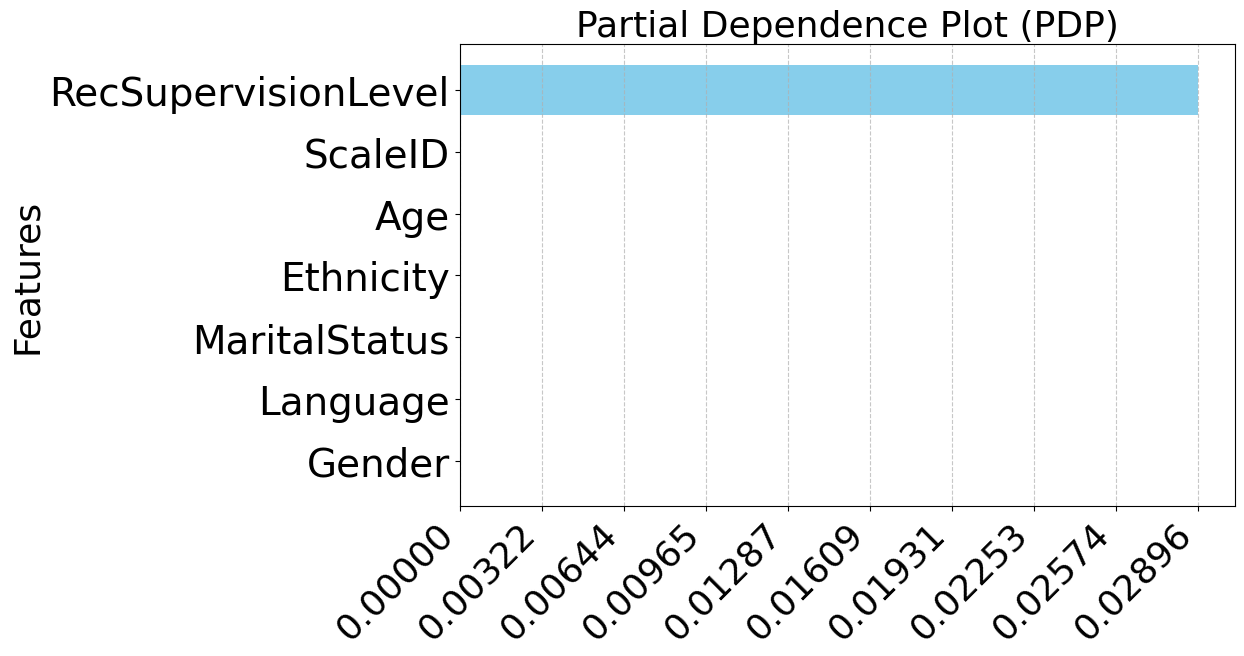

In [22]:
start_pdp = time.time()

# Load the dataset
pdp_data = pd.read_csv(path)

# Separate target variable and features
pdp_target = pdp_data['class'].copy()
pdp_features = pdp_data.drop(columns=['class']).copy()

# Split into training and test sets (PDP-specific)
X_train_pdp, X_test_pdp, y_train_pdp, y_test_pdp = train_test_split(pdp_features, pdp_target, test_size=0.2, random_state=42)

# Identify categorical and numerical columns
pdp_categorical_cols = pdp_features.select_dtypes(include=['object', 'category']).columns.tolist()
pdp_numerical_cols = [c for c in pdp_features.columns if c not in pdp_categorical_cols]

# Preprocessor: Pass numerical columns through without encoding
pdp_preprocessor = ColumnTransformer([
    ('num', 'passthrough', pdp_numerical_cols)
])

# Build the pipeline: preprocessing + classifier
pdp_pipeline = Pipeline([
    ('preproc', pdp_preprocessor),
    ('clf', deepcopy(pick_mdl))
])
pdp_pipeline.fit(X_train_pdp, y_train_pdp)

# Manually compute Partial Dependence Plots (PDP)
pdp_importance_values = []
pdp_feature_names = pdp_features.columns.tolist()
pdp_grid_resolution = 20

for feature in pdp_feature_names:
    if pdp_features[feature].dtype.kind in 'biufc':
        grid = np.linspace(pdp_features[feature].min(), pdp_features[feature].max(), pdp_grid_resolution)
    else:
        grid = np.unique(pdp_features[feature])
    
    pdp_means = []
    for val in grid:
        X_temp_pdp = X_test_pdp.copy()
        X_temp_pdp[feature] = val
        preds = pdp_pipeline.predict_proba(X_temp_pdp)[:, 1]
        pdp_means.append(preds.mean())
    
    pdp_importance_values.append(np.var(pdp_means))

# Create DataFrame of feature importances and sort
pdp_importance_df = pd.DataFrame({
    'feature_importance': pdp_importance_values
}, index=pdp_feature_names).sort_values('feature_importance', ascending=False)

# Extract top k features and their importance values
top_pdp_features = pdp_importance_df.index.tolist()[:group_size]
top_pdp_values = pdp_importance_df['feature_importance'].tolist()[:group_size]

# Plot bar chart for the top k features
plt.figure(figsize=(10, 6))
plt.barh(pdp_importance_df.index[:group_size], pdp_importance_df['feature_importance'][:group_size], color='skyblue')
plt.ylabel('Features', fontsize=26)
xtick_values = np.linspace(min(top_pdp_values), max(top_pdp_values), num=10)
plt.xticks(xtick_values, fontsize=26, rotation=45, ha='right')
plt.title('Partial Dependence Plot (PDP)', fontsize=26)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(fontsize=28)
plt.gca().invert_yaxis()
plt.show()

# Prepare selected features for accuracy testing
pdp_selected_features = top_pdp_features[:group_size]
pdp_selected_features.sort()
pdp_selected_features.append('class')

# Compute accuracy for the selected features
pdp_acc = str(compute_accuracy(path, pdp_selected_features, deepcopy(pick_mdl))).replace('.', ',')

# Calculate execution time
end_pdp = time.time()
t_pdp = end_pdp - start_pdp

# Create dictionary of PDP feature importances
pdp_dict = dict(zip(top_pdp_features, top_pdp_values))


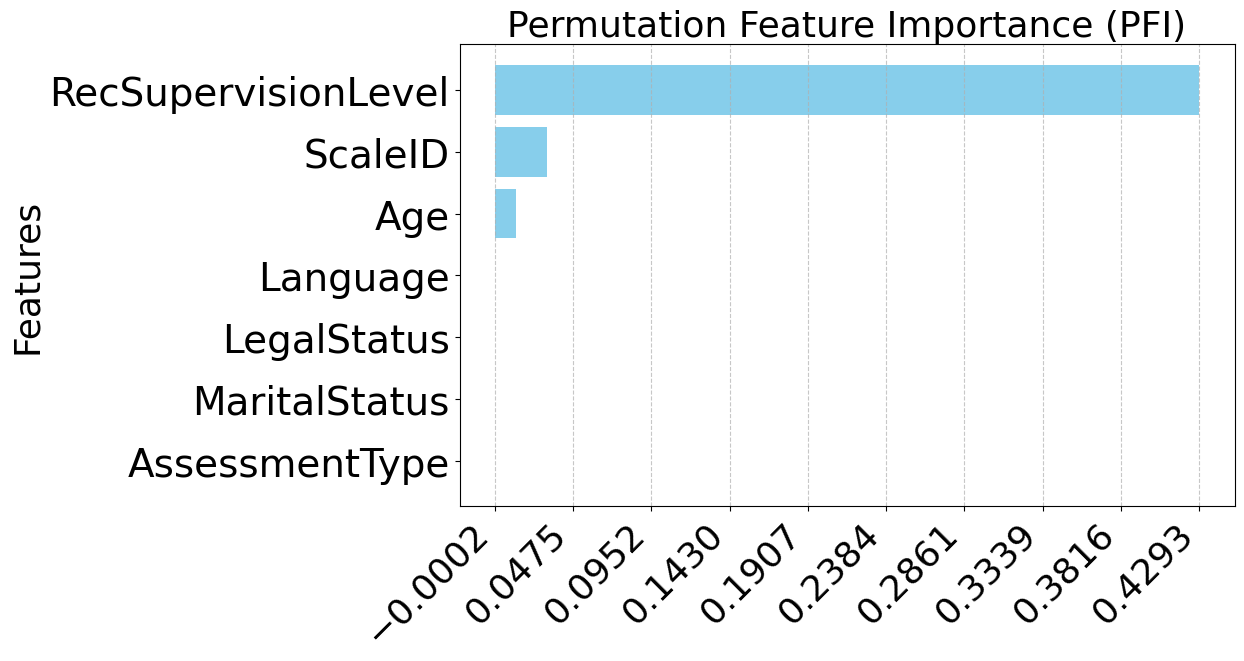

In [23]:
pfi_start_time = time.time()

# Load the dataset
pfi_data = pd.read_csv(path)

# Separate target variable and features
pfi_target = pfi_data['class'].copy()
pfi_features = pfi_data.drop(columns=['class']).copy()

# Split data into training and test sets (PFI-specific)
X_train_pfi, X_test_pfi, y_train_pfi, y_test_pfi = train_test_split(pfi_features, pfi_target, test_size=0.2, random_state=42)

# Train the model (PFI-specific)
pfi_model = deepcopy(pick_mdl)
pfi_model.fit(X_train_pfi, y_train_pfi)

# Calculate Permutation Importance
pfi_importance = permutation_importance(
    pfi_model, X_test_pfi, y_test_pfi, n_repeats=10, random_state=42, n_jobs=-1
)

# Create a DataFrame for feature importances and sort descending
pfi_importance_df = pd.DataFrame(
    pfi_importance.importances_mean,
    index=pfi_features.columns,
    columns=['feature_importance']
)
pfi_importance_df.sort_values(by='feature_importance', ascending=False, inplace=True)

# Extract top features and their importance values
pfi_top_features = pfi_importance_df.index.tolist()[:group_size]
pfi_top_values = pfi_importance_df['feature_importance'].tolist()[:group_size]

# Plot Permutation Importance
plt.figure(figsize=(10, 6))
plt.barh(pfi_importance_df.index[:group_size], pfi_importance_df['feature_importance'][:group_size], color='skyblue')
plt.ylabel('Features', fontsize=26)
pfi_xtick_values = np.linspace(min(pfi_top_values), max(pfi_top_values), num=10)
plt.xticks(pfi_xtick_values, fontsize=26, rotation=45, ha='right')
plt.title('Permutation Feature Importance (PFI)', fontsize=26)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(fontsize=28)
plt.gca().invert_yaxis()
plt.show()

# Prepare selected features for accuracy testing
pfi_selected_features = pfi_top_features
pfi_selected_features.sort()
pfi_selected_features.append('class')

# Compute accuracy for the selected features
pfi_acc = str(compute_accuracy(path, pfi_selected_features, deepcopy(pick_mdl))).replace('.', ',')

# Calculate total execution time
t_pfi = time.time() - pfi_start_time

# Create dictionary of PFI feature importances
pfi_dict = dict(zip(pfi_top_features, pfi_top_values))


In [24]:
def featureAcc(d_f, model, feature):
    dataf = d_f.loc[:, feature].copy()
    y = dataf["class"]
    X = dataf.drop(columns=["class"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc



t_sc= cfw.alg_consistency

In [25]:
# Function to evaluate Fidelity
def evaluate_fidelity(
    model,
    X_train,
    X_test,
    importance_scores,
    top_k=7,
    metric='accuracy',
    max_depth='auto',
    random_state=42,
    verbose=False,
    epsilon=1e-3,
    normalize=False,
):
    # 1) Convert importance scores to a pandas Series
    imp = pd.Series(importance_scores, index=X_train.columns,
                    name='Importance', dtype=float)
    if normalize:
        max_abs = imp.abs().max()
        if max_abs > 0:
            imp = imp / max_abs

    # 2) Filter features with importance above epsilon
    imp_abs = imp.abs()
    imp_filtered = imp_abs[imp_abs > epsilon]
    if imp_filtered.empty:
        if verbose:
            print(f"No features above |epsilon|={epsilon}, falling back.")
        imp_filtered = imp_abs

    # 3) Select top-k most important features
    top_feats = imp_filtered.sort_values(ascending=False)\
                             .head(top_k).index.tolist()
    if verbose:
        print("Features used:", top_feats)

    # 4) Get predictions of the black-box model
    y_bb_train = model.predict(X_train)
    y_bb_test  = model.predict(X_test)

    # 5) Choose the best depth for the surrogate model (DecisionTree)
    if max_depth == 'auto':
        param_grid = {'max_depth': list(range(2, 11))}
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        gs = GridSearchCV(
            DecisionTreeClassifier(random_state=random_state),
            param_grid,
            scoring='accuracy',
            cv=cv,
            n_jobs=-1
        )
        gs.fit(X_train[top_feats], y_bb_train)
        best_depth = gs.best_params_['max_depth']
    else:
        best_depth = max_depth
    if verbose:
        print(f"Chosen max_depth: {best_depth}")

    # 6) Train the surrogate model on top-k features
    surrogate = DecisionTreeClassifier(max_depth=best_depth, random_state=random_state)
    surrogate.fit(X_train[top_feats], y_bb_train)

    # 7) Calculate fidelity (accuracy or F1 between surrogate and black-box predictions)
    y_surr = surrogate.predict(X_test[top_feats])
    if metric == 'accuracy':
        fidelity = accuracy_score(y_bb_test, y_surr)
    else:
        fidelity = f1_score(y_bb_test, y_surr, average='weighted')
    if verbose:
        print(f"Fidelity: {fidelity:.4f}")

    return fidelity, surrogate

# Function to evaluate Faithfulness


from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.utils import check_random_state
from scipy.stats import spearmanr

# V2'den farklı olarak güncellendi
def evaluate_faithfulness(
    model,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    importance_scores: dict,
    *,
    # --- legacy arguments ---
    top_k: int = 7,
    metric: str = "accuracy",
    random_state: int = 42,
    runs_per_feature: int = 30,
    epsilon: float = 1e-8,
    normalize: bool = False,
    verbose: bool = False,
    grid_resolution: int = 30,
    pdp_percentiles: tuple = (0.05, 0.95),
    # --- new arguments ---
    drop_mode: str = "metric",       # "metric" | "prob"
    class_id: int | None = None,     # for drop_mode="prob" (probability column index)
    abs_drop: bool = True,           # take |.| of the probability drop
    conditional_permutation: bool = False,  # more robust to correlation
    # --- practical: optional PD-variance computation ---
    compute_pd_var: bool = False,
    # --- parallel ---
    n_jobs: int = 1,
    prefer: str = "threads",
):
    """
Compute feature faithfulness using either:
  - drop in a classic performance metric (accuracy/f1/log_loss), or
  - drop in the predicted class probability.

Returns
-------
faithfulness : float
drop_impacts : dict[str, float]
(optional) pd_var : dict[str, float]
    Only returned when compute_pd_var=True.
"""

    # ------- 1) Importance scores + filtering ---------------------------- #
    imp = pd.Series(importance_scores, dtype=float)
    if normalize:
        m = imp.abs().max()
        if m > 0:
            imp /= m

    active = imp.abs() > epsilon
    feats = (
        imp.loc[active].abs().nlargest(top_k).index.tolist()
        if active.any() and 0 < top_k < active.sum()
        else imp.loc[active].index.tolist() if active.any()
        else imp.index.tolist()
    )
    if verbose:
        print(f"Selected {len(feats)} features:", ", ".join(feats))

    # ------- 2) Baseline score / probability ---------------------------- #
    metric = metric.lower()
    if drop_mode == "metric":
        if metric == "accuracy":
            scorer = accuracy_score
        elif metric == "f1":
            scorer = lambda y, yp: f1_score(y, yp, average="weighted")
        elif metric == "log_loss":
            if not hasattr(model, "predict_proba"):
                raise ValueError("metric='log_loss' requires model.predict_proba.")
            base_score = -log_loss(y_test, model.predict_proba(X_test))  # higher = better
            scorer = None
        else:
            raise ValueError(f"Unsupported metric: {metric}")

        if metric != "log_loss":
            y_pred_base = model.predict(X_test)
            base_score = scorer(y_test, y_pred_base)

    elif drop_mode == "prob":
        if not hasattr(model, "predict_proba"):
            raise ValueError("drop_mode='prob' requires model.predict_proba.")
        if class_id is None:
            class_id_vec = y_test.to_numpy()
            proba = model.predict_proba(X_test)
            base_scores = proba[np.arange(len(X_test)), class_id_vec]
        else:
            base_scores = model.predict_proba(X_test)[:, class_id]
    else:
        raise ValueError("drop_mode must be 'metric' or 'prob'.")

    if verbose and drop_mode == "metric":
        print(f"Base {metric}: {base_score:.4f}")

    # ------- 3) Impact via permutation ---------------------------------- #
    rng_master = check_random_state(random_state)

    # For conditional_permutation: precompute bin indices once per feature
    groups_map: Dict[str, List[np.ndarray]] = {}
    if conditional_permutation:
        for f in feats:
            q = pd.qcut(X_test[f], q=10, duplicates="drop")
            groups: List[np.ndarray] = []
            for cat in q.unique():
                idx = np.where(q == cat)[0]
                if len(idx) > 1:
                    groups.append(idx)
            groups_map[f] = groups

    # Pre-generate per-run seeds for deterministic parallel execution
    seeds_map: Dict[str, np.ndarray] = {
        f: rng_master.randint(0, np.iinfo(np.int32).max, size=runs_per_feature)
        for f in feats
    }

    def _impact_one_run(f: str, seed: int) -> float:
        rng = np.random.RandomState(int(seed))
        Xp = X_test.copy()
        col = Xp[f].to_numpy().copy()

        if conditional_permutation:
            for idx in groups_map.get(f, []):
                rng.shuffle(col[idx])
        else:
            rng.shuffle(col)

        Xp[f] = col

        if drop_mode == "metric":
            if metric == "log_loss":
                score = -log_loss(y_test, model.predict_proba(Xp))
            else:
                score = scorer(y_test, model.predict(Xp))
            return float(base_score - score)

        # "prob"
        proba = model.predict_proba(Xp)
        if class_id is None:
            p = proba[np.arange(len(Xp)), class_id_vec]
        else:
            p = proba[:, class_id]

        diff = base_scores - p
        if abs_drop:
            diff = np.abs(diff)
        else:
            diff = np.maximum(diff, 0)
        return float(np.mean(diff))

    def _impact_for_feature(f: str) -> Tuple[str, float]:
        impacts = [_impact_one_run(f, s) for s in seeds_map[f]]
        return f, float(np.mean(impacts))

    if (n_jobs is None) or (int(n_jobs) == 1) or (len(feats) <= 1):
        drop_impacts = dict(_impact_for_feature(f) for f in feats)
    else:
        results = Parallel(n_jobs=n_jobs, prefer=prefer)(
            delayed(_impact_for_feature)(f) for f in feats
        )
        drop_impacts = dict(results)

    if verbose:
        for f in feats:
            print(f"Impact {f}: {drop_impacts[f]:.4f}")

    # ------- 4) (Optional) PD variance ---------------------------------- #
    pd_var: Dict[str, float] = {}
    if compute_pd_var:
        # Note: PD variance is NOT included in faithfulness. It is only diagnostic.
        target_col = None
        # Caution: predict_proba(...).mean(axis=1) can become uninformative in multiclass.
        # Here we track class_id if provided; otherwise we track the true-class column.
        if hasattr(model, "predict_proba"):
            if (drop_mode == "prob") and (class_id is not None):
                target_col = class_id
            else:
                # true-class column (assumes label == column index) – consistent with the previous setup
                target_col = None

        low_p, high_p = pdp_percentiles

        def _pd_var_for_feature(f: str) -> Tuple[str, float]:
            low, high = X_train[f].quantile(low_p), X_train[f].quantile(high_p)
            grid = np.linspace(low, high, grid_resolution)

            pd_mat = np.zeros((len(X_test), len(grid)))
            for i, v in enumerate(grid):
                Xt = X_test.copy()
                Xt[f] = v
                if hasattr(model, "predict_proba"):
                    proba = model.predict_proba(Xt)
                    if target_col is not None:
                        pr = proba[:, target_col]
                    else:
                        cls = y_test.to_numpy()
                        pr = proba[np.arange(len(Xt)), cls]
                else:
                    pr = model.predict(Xt)
                pd_mat[:, i] = pr

            return f, float(np.mean(np.var(pd_mat, axis=1)))

        if (n_jobs is None) or (int(n_jobs) == 1) or (len(feats) <= 1):
            pd_var = dict(_pd_var_for_feature(f) for f in feats)
        else:
            results = Parallel(n_jobs=n_jobs, prefer=prefer)(
                delayed(_pd_var_for_feature)(f) for f in feats
            )
            pd_var = dict(results)

        if verbose:
            for f in feats:
                print(f"PD-var {f}: {pd_var[f]:.4f}")

        # ------- 5) Spearman correlation ------------------------------------ #
    imp_vals = [imp.abs()[f] for f in feats]
    impact_vals = [drop_impacts[f] for f in feats]

    if len(set(imp_vals)) <= 1 or len(set(impact_vals)) <= 1:
        faithfulness = 0.0
        if verbose:
            print("No variance → faithfulness = 0")
    else:
        faithfulness, _ = spearmanr(imp_vals, impact_vals)
        if verbose:
            print(f"Faithfulness (Spearman): {faithfulness:.4f}")

    if compute_pd_var:
        return faithfulness, drop_impacts, pd_var
    return faithfulness, drop_impacts


# Example usage: Testing multiple importance methods (val_impact, SHAP, PDP, PFI, ALE)
if __name__ == '__main__':
    split = cfw.get_splits()

    X_train = pd.DataFrame(split.X_train, columns=split.feature_names)
    y_train = pd.Series(split.y_train)

    # Eğer tuner optimize için X_opt kullandıysa:
    X_opt  = pd.DataFrame(split.X_opt, columns=split.feature_names)
    y_opt  = pd.Series(split.y_opt)

    # For the final report, X_eval:
    X_test = pd.DataFrame(split.X_test, columns=split.feature_names)  # eval/test
    y_test = pd.Series(split.y_test)

    bb_model = deepcopy(pick_mdl)
    bb_model.fit(X_train, y_train)

    fidel_fix, _ = evaluate_fidelity(bb_model, X_train, X_test, p)
    faith_fix, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, p)
    fidel_shap, _ = evaluate_fidelity(bb_model, X_train, X_test, shap_dict)
    faith_shap, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, shap_dict)
    fidel_pdp, _ = evaluate_fidelity(bb_model, X_train, X_test, pdp_dict)
    faith_pdp, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, pdp_dict)
    fidel_pfi, _ = evaluate_fidelity(bb_model, X_train, X_test, pfi_dict)
    faith_pfi, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, pfi_dict)
    fidel_ale, _ = evaluate_fidelity(bb_model, X_train, X_test, ale_dict)
    faith_ale, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, ale_dict)

In [26]:
#Calculating the running time of the our algorithm
startTime = time.time()
cfw.prepare_data()
cfw.select_features()
cfw.combFeatures()
endTime=time.time()
t1 = endTime - startTime
print("Time:",round(t1,2))

Time: 10.48


In [27]:
def bold_(text):
    return(f"\033[1m{text}\033[0m")

all_accuracy = compute_accuracy(path, None, deepcopy(pick_mdl))

In [28]:
print(bold_("Number of Data: "), cfw.num_of_data)
print(bold_("Number of Class: "), cfw.num_of_class)
print(bold_("Number of Features: "), cfw.num_of_feature)
print(bold_("Selected Model : "),type(pick_mdl).__name__)
print("\n")

print(bold_("fixAIt Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),p.keys())
print(bold_("Accuracy value of selected features: "), cfw.acc_select)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'fiXAIt → Fidelity: {fidel_fix:.4f} | Faithfulness: {faith_fix:.4f}')
print(bold_("fiXAIt Self-Consistency: "), round(t_sc,3))
print(bold_("Algorithm Run Time (sec): "), round(t1,2))

print("\n")
print(bold_("SHAP Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),shap_selected_features[:-1])
print(bold_("Accuracy value of selected features: "), shap_acc)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'Shap → Fidelity: {fidel_shap:.4f} | Faithfulness: {faith_shap:.4f}')
print(bold_("Algorithm Run Time (sec): "), round(t_shap,2))

print("\n")
print(bold_("ALE Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),ale_top_features[:-1])
print(bold_("Accuracy value of selected features: "), ale_acc)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'ALE → Fidelity: {fidel_ale:.4f} | Faithfulness: {faith_ale:.4f}')
print(bold_("Algorithm Run Time (sec): "), round(t_ale,2))

print("\n")
print(bold_("PDP Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),pdp_selected_features[:-1])
print(bold_("Accuracy value of selected features: "), pdp_acc)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'\nPDP → Fidelity: {fidel_pdp:.4f} | Faithfulness: {faith_pdp:.4f}')
print(bold_("Algorithm Run Time (sec): "), round(t_pdp,2))

print("\n")
print(bold_("PFI Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),pfi_selected_features[:-1])
print(bold_("Accuracy value of selected features: "), pfi_acc)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'PFI → Fidelity: {fidel_pfi:.4f} | Faithfulness: {faith_pfi:.4f}')
print(bold_("Algorithm Run Time (sec): "), round(t_pfi,2))

Number of Data:  15038
Number of Class:  3
Number of Features:  10
Selected Model :  CatBoostClassifier


fixAIt Algorithm
	↓
Selected features:  dict_keys(['Age', 'RecSupervisionLevel', 'ScaleID'])
Accuracy value of selected features:  0.843
Accuracy value of all features:  0.834
fiXAIt → Fidelity: 1.0000 | Faithfulness: 1.0000
fiXAIt Self-Consistency:  0.919
Algorithm Run Time (sec):  10.48


SHAP Algorithm
	↓
Selected features:  ['Age', 'CustodyStatus', 'Ethnicity', 'Gender', 'MaritalStatus', 'RecSupervisionLevel']
Accuracy value of selected features:  0,834
Accuracy value of all features:  0.834
Shap → Fidelity: 1.0000 | Faithfulness: 0.9063
Algorithm Run Time (sec):  1.91


ALE Algorithm
	↓
Selected features:  ['RecSupervisionLevel', 'ScaleID', 'Age', 'Ethnicity', 'MaritalStatus', 'Gender']
Accuracy value of selected features:  0.835
Accuracy value of all features:  0.834
ALE → Fidelity: 0.9464 | Faithfulness: 0.9063
Algorithm Run Time (sec):  1.85


PDP Algorithm
	↓
Selected feat